# Urban Heat Island Analysis — Tondo, Manila (v5)
## MSF Geo-Humanitarian Project · University of Salzburg Z_GIS

---

### Pipeline overview

```
Step 1: Configuration (AOI, dates, thresholds)
Step 2: Landsat 8+9 acquisition → LST, NDVI, NDBI, MNDWI at 30 m
Step 3: MODIS Terra+Aqua acquisition → LST at 1 km (for spatial fusion)
Step 4: Sentinel-3 SLSTR acquisition → LST at 1 km (for temporal calibration)
Step 5: Seasonal composites (dry / wet / annual)
Step 6: Regression-based fusion (MODIS 1 km → 30 m) + S3 temporal correction
Step 7: Monthly fused LST time-series
Step 8: UHI intensity maps
Step 9: Ancillary data (population, built-up, vegetation, health)
Step 10: Statistical analysis + LST threshold classification
Step 11: Vulnerability index + barangay ranking
Step 12: Export + cooling site identification
```

### Why two coarse thermal sources?
- **MODIS** (GEE) → provides **spatial** LST variation at 1 km for regression downscaling
- **Sentinel-3 SLSTR** (CDSE) → provides independent **temporal** LST observations for calibration

---

## Step 0 · Setup

**Google Earth Engine**: [code.earthengine.google.com/register](https://code.earthengine.google.com/register) → create Cloud Project → enable EE API

**Copernicus Data Space** (free, for Sentinel-3): [dataspace.copernicus.eu](https://dataspace.copernicus.eu) → register → use email + password below

---

In [1]:
# ----------------------------------------------------------------------
# 0A · Install packages
# ----------------------------------------------------------------------
!pip install earthengine-api folium pandas matplotlib seaborn geopandas xarray netCDF4 requests -q
print("All packages installed.")

All packages installed.


In [2]:
# ----------------------------------------------------------------------
# 0B · Authenticate Earth Engine + Copernicus Data Space
# ----------------------------------------------------------------------

# ---- Google Earth Engine ----
GEE_PROJECT = "uhi-msf-analysis"  # Replace with your project ID

import ee
ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)
print(f"GEE ready: {GEE_PROJECT}")

# ---- Copernicus Data Space (for Sentinel-3 SLSTR) ----
import requests

CDSE_USERNAME = "************"  # <-- your CDSE email
CDSE_PASSWORD = "*********"            # <-- your CDSE password


def get_cdse_token():
    """Authenticate with Copernicus Data Space and return an access token."""
    response = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token",
        data={
            "grant_type": "password",
            "username": CDSE_USERNAME,
            "password": CDSE_PASSWORD,
            "client_id": "cdse-public",
        })
    if response.status_code == 200:
        print("CDSE authenticated.")
        return response.json()["access_token"]
    else:
        print(f"CDSE authentication failed (status {response.status_code}).")
        return None

cdse_token = get_cdse_token()

GEE ready: uhi-msf-analysis
CDSE authenticated.


In [3]:
# ----------------------------------------------------------------------
# 0C · Import libraries and define map utilities
# ----------------------------------------------------------------------
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import json, os, tempfile, warnings
warnings.filterwarnings("ignore")
from datetime import datetime

def add_ee_layer(folium_map, ee_image, vis_params, layer_name, shown=True):
    """Add a Google Earth Engine image as a tile layer on a folium map.
    
    Parameters
    ----------
    folium_map : folium.Map
    ee_image   : ee.Image — the image to display
    vis_params : dict     — e.g. {'min': 25, 'max': 45, 'palette': [...]}
    layer_name : str      — label in the layer control
    shown      : bool     — whether this layer is visible by default
    """
    map_id = ee_image.getMapId(vis_params)
    folium.TileLayer(
        tiles=map_id["tile_fetcher"].url_format,
        attr="Google Earth Engine",
        name=layer_name,
        overlay=True,
        control=True,
        show=shown
    ).add_to(folium_map)

def make_map(center_lat, center_lon, zoom=14):
    """Create a folium base map."""
    return folium.Map(location=[center_lat, center_lon], zoom_start=zoom, tiles="OpenStreetMap")

print("Libraries loaded.")

Libraries loaded.


---
## Step 1 · Configuration

**Edit this cell only.** Everything downstream adapts automatically.

---

In [4]:
# ----------------------------------------------------------------------
# STEP 1 · Configuration — edit these values for your study area
# ----------------------------------------------------------------------

# Area of Interest: [west, south, east, north] in decimal degrees
AOI_BBOX = [120.950, 14.600, 120.985, 14.640]   # Tondo, Manila

# To use a GEE asset instead of a bounding box, uncomment:
# AOI_ASSET  = "FAO/GAUL/2015/level2"
# AOI_FILTER = ee.Filter.eq("ADM2_NAME", "Manila")

# Study period
YEAR_START = 2019
YEAR_END   = 2025

# Seasons (month numbers)
DRY_MONTHS = [12, 1, 2, 3, 4, 5]   # Philippine dry season
WET_MONTHS = [6, 7, 8, 9, 10, 11]  # Philippine wet season

# Maximum cloud cover for Landsat scene selection (percent)
MAX_CLOUD_COVER = 30

# Buffer around AOI to define the "reference ring" for UHI calculation (meters)
UHI_BUFFER_M = 5000

# LST thresholds for heat classification (Celsius)
LST_EXTREME = 35   # >= this = extreme heat
LST_MODERATE = 30  # >= this and < extreme = moderate heat
                    # < moderate = cool / normal

# Vulnerability index weights (must sum to 1.0)
W_LST    = 0.30   # land surface temperature
W_POP    = 0.25   # population density
W_BUILD  = 0.20   # built-up surface fraction
W_NDVI   = 0.15   # vegetation deficit (inverted NDVI)
W_HEALTH = 0.10   # distance to health facilities

PROJECT_NAME = "UHI_Tondo_Manila"

# Validation
assert abs(W_LST + W_POP + W_BUILD + W_NDVI + W_HEALTH - 1.0) < 0.001, "Weights must sum to 1.0"
print(f"Project    : {PROJECT_NAME}")
print(f"AOI        : {AOI_BBOX}")
print(f"Period     : {YEAR_START} – {YEAR_END}")
print(f"Thresholds : Extreme >= {LST_EXTREME}°C | Moderate >= {LST_MODERATE}°C")

Project    : UHI_Tondo_Manila
AOI        : [120.95, 14.6, 120.985, 14.64]
Period     : 2019 – 2025
Thresholds : Extreme >= 35°C | Moderate >= 30°C


## Step 2 · Define Area of Interest

In [5]:
# ----------------------------------------------------------------------
# STEP 2 · Build AOI geometry and reference ring
# ----------------------------------------------------------------------

# Build the study area polygon
try:
    # Option B: from a GEE asset (if AOI_ASSET is defined)
    aoi = ee.FeatureCollection(AOI_ASSET).filter(AOI_FILTER).geometry()
    print("AOI loaded from GEE asset.")
except NameError:
    # Option A: from bounding box coordinates
    aoi = ee.Geometry.Rectangle(AOI_BBOX)
    print("AOI created from bounding box.")

# Reference ring: a buffer around the AOI, excluding the AOI itself.
# Used to compute the "background" temperature for UHI intensity.
aoi_buffer = aoi.buffer(UHI_BUFFER_M)
aoi_ring   = aoi_buffer.difference(aoi)

# Map center for visualization
center_lat = (AOI_BBOX[1] + AOI_BBOX[3]) / 2
center_lon = (AOI_BBOX[0] + AOI_BBOX[2]) / 2

# Preview
m0 = make_map(center_lat, center_lon, zoom=13)
folium.GeoJson(aoi.getInfo(), name="Study Area (AOI)",
               style_function=lambda x: {"color": "red", "weight": 2, "fillOpacity": 0.1}).add_to(m0)
folium.GeoJson(aoi_ring.getInfo(), name="Reference Ring (for UHI)",
               style_function=lambda x: {"color": "blue", "weight": 1, "fillOpacity": 0.05}).add_to(m0)
folium.LayerControl().add_to(m0)
m0

AOI created from bounding box.


## Step 3 · Landsat 8 + 9 Acquisition

Landsat provides 30 m resolution imagery with:
- **LST** from the thermal band (ST_B10)
- **NDVI** (vegetation), **NDBI** (built-up), **MNDWI** (water) from optical bands

Combining Landsat 8 and 9 gives ~8-day revisit instead of 16.


In [6]:
# ----------------------------------------------------------------------
# STEP 3A · Processing functions for Landsat
# ----------------------------------------------------------------------
# Each function takes an ee.Image and returns it with a new band added.

def mask_landsat_clouds(image):
    """Mask cloud and cloud-shadow pixels using the QA_PIXEL band.
    Bit 3 = cloud, Bit 4 = cloud shadow. Both must be 0 (clear)."""
    qa = image.select("QA_PIXEL")
    clear = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(clear)

def compute_lst(image):
    """Derive Land Surface Temperature (°C) from Landsat Collection 2 Level 2.
    Band ST_B10: scale = 0.00341802, offset = 149.0 → Kelvin → subtract 273.15."""
    kelvin = image.select("ST_B10").multiply(0.00341802).add(149.0)
    celsius = kelvin.subtract(273.15).rename("LST")
    return image.addBands(celsius)

def compute_spectral_indices(image):
    """Compute three spectral indices from Landsat OLI bands:
    - NDVI  (vegetation)  = (NIR - Red)  / (NIR + Red)      → SR_B5, SR_B4
    - NDBI  (built-up)    = (SWIR1 - NIR) / (SWIR1 + NIR)   → SR_B6, SR_B5
    - MNDWI (water)       = (Green - SWIR1) / (Green + SWIR1) → SR_B3, SR_B6
    """
    ndvi  = image.normalizedDifference(["SR_B5", "SR_B4"]).rename("NDVI")
    ndbi  = image.normalizedDifference(["SR_B6", "SR_B5"]).rename("NDBI")
    mndwi = image.normalizedDifference(["SR_B3", "SR_B6"]).rename("MNDWI")
    return image.addBands(ndvi).addBands(ndbi).addBands(mndwi)

def add_time_metadata(image):
    """Tag each image with year and month for later filtering."""
    date = image.date()
    return image.set("year", date.get("year")).set("month", date.get("month"))

print("Landsat processing functions defined.")

Landsat processing functions defined.


In [7]:
# ----------------------------------------------------------------------
# STEP 3B · Load and process Landsat 8 + 9 imagery
# ----------------------------------------------------------------------

# Landsat 9 (launched 2021, but we include it for the full study period)
landsat_9 = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31")
    .filter(ee.Filter.lt("CLOUD_COVER", MAX_CLOUD_COVER))
    .map(mask_landsat_clouds)
    .map(compute_lst)
    .map(compute_spectral_indices)
    .map(add_time_metadata)
)

# Landsat 8 (available from 2013)
landsat_8 = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31")
    .filter(ee.Filter.lt("CLOUD_COVER", MAX_CLOUD_COVER))
    .map(mask_landsat_clouds)
    .map(compute_lst)
    .map(compute_spectral_indices)
    .map(add_time_metadata)
)

# Merge into one collection, sorted by date
landsat_combined = landsat_8.merge(landsat_9).sort("system:time_start")

# Report
n_l8 = landsat_8.size().getInfo()
n_l9 = landsat_9.size().getInfo()
n_total = landsat_combined.size().getInfo()
print(f"Landsat 8 : {n_l8} scenes")
print(f"Landsat 9 : {n_l9} scenes")
print(f"Combined  : {n_total} scenes")

dates = landsat_combined.aggregate_array("system:time_start").getInfo()
if dates:
    date_strings = [datetime.utcfromtimestamp(d / 1000).strftime("%Y-%m-%d") for d in dates]
    print(f"Date range: {min(date_strings)} → {max(date_strings)}")

# Verify bands are present
sample_bands = landsat_combined.first().bandNames().getInfo()
expected = ["LST", "NDVI", "NDBI", "MNDWI"]
for band in expected:
    status = "✓" if band in sample_bands else "✗ MISSING"
    print(f"  {status} {band}")

Landsat 8 : 47 scenes
Landsat 9 : 27 scenes
Combined  : 74 scenes
Date range: 2019-01-04 → 2025-12-30
  ✓ LST
  ✓ NDVI
  ✓ NDBI
  ✓ MNDWI


## Step 4 · Coarse-Resolution Thermal Data

Two sources, two roles:

| Source | Resolution | Role | Access |
|--------|-----------|------|--------|
| **MODIS** Terra+Aqua | 1 km | Spatial fusion (has pixel-level variation in GEE) | Google Earth Engine |
| **Sentinel-3 SLSTR** | 1 km | Temporal calibration (independent thermal obs) | Copernicus Data Space |

**Why not use S3 for regression?** The CDSE Nodes API returns LST values for our small AOI (~3×4 km), which at 1 km resolution is only a handful of pixels. After averaging, it becomes a single constant — and regression against a constant gives zero coefficients. MODIS is already gridded in GEE at 1 km with full spatial variation, making it the right choice for spatial downscaling.


In [8]:
# ----------------------------------------------------------------------
# STEP 4A · MODIS LST (Terra + Aqua) — used for spatial fusion
# ----------------------------------------------------------------------

def process_modis_lst(image):
    """Convert MODIS LST from Kelvin (scale 0.02) to Celsius.
    QC_Day bits 0-1: 00 = good quality."""
    lst_celsius = image.select("LST_Day_1km").multiply(0.02).subtract(273.15).rename("LST_MODIS")
    quality_ok = image.select("QC_Day").bitwiseAnd(3).eq(0)
    return image.addBands(lst_celsius).updateMask(quality_ok)

# Terra (morning overpass)
modis_terra = (
    ee.ImageCollection("MODIS/061/MOD11A1")
    .filterBounds(aoi)
    .filterDate(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31")
    .map(process_modis_lst)
)

# Aqua (afternoon overpass)
modis_aqua = (
    ee.ImageCollection("MODIS/061/MYD11A1")
    .filterBounds(aoi)
    .filterDate(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31")
    .map(process_modis_lst)
)

# Merge both → ~2 observations per day
modis_combined = modis_terra.merge(modis_aqua).sort("system:time_start").map(add_time_metadata)

n_modis = modis_combined.size().getInfo()
print(f"MODIS (Terra + Aqua): {n_modis} scenes (1 km, ~2x daily)")

MODIS (Terra + Aqua): 5084 scenes (1 km, ~2x daily)


In [9]:
# ----------------------------------------------------------------------
# STEP 4B · Sentinel-3 SLSTR LST via CDSE Nodes API
# ----------------------------------------------------------------------
# Downloads only LST_in.nc (~1 MB) + geodetic_in.nc (~1 MB) per scene
# instead of the full product zip (~100-200 MB).
# Produces a monthly mean LST for the AOI.

s3_monthly_means = {}  # {(year, month): float} — monthly mean LST in Celsius

if cdse_token:
    print("Fetching Sentinel-3 SLSTR LST from CDSE (individual files only)...")
    west, south, east, north = AOI_BBOX
    buf_deg = UHI_BUFFER_M / 111000  # approximate buffer in degrees
    search_west  = west  - buf_deg
    search_south = south - buf_deg
    search_east  = east  + buf_deg
    search_north = north + buf_deg
    active_token = cdse_token
    scenes_read = 0

    for yr in range(YEAR_START, YEAR_END + 1):
        for mo in range(1, 13):
            start_dt = f"{yr}-{mo:02d}-01T00:00:00.000Z"
            if mo < 12:
                end_dt = f"{yr}-{mo+1:02d}-01T00:00:00.000Z"
            else:
                end_dt = f"{yr+1}-01-01T00:00:00.000Z"

            # Search CDSE catalogue for SL_2_LST products
            search_url = (
                "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
                f"?$filter=Collection/Name eq 'SENTINEL-3'"
                f" and Attributes/OData.CSC.StringAttribute/any("
                f"att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq 'SL_2_LST___')"
                f" and OData.CSC.Intersects(area=geography'SRID=4326;POLYGON(("
                f"{search_west} {search_south},{search_east} {search_south},"
                f"{search_east} {search_north},{search_west} {search_north},"
                f"{search_west} {search_south}))')"
                f" and ContentDate/Start gt {start_dt}"
                f" and ContentDate/Start lt {end_dt}"
                f"&$top=30&$orderby=ContentDate/Start asc"
            )

            try:
                catalogue_results = requests.get(search_url, timeout=30).json().get("value", [])
            except Exception:
                continue

            if not catalogue_results:
                continue

            lst_pixel_values = []

            # Download only 3 scenes per month (enough for a mean, keeps it fast)
            for product in catalogue_results[:3]:
                product_id   = product["Id"]
                product_name = product["Name"]

                try:
                    headers = {"Authorization": f"Bearer {active_token}"}

                    # Nodes API: download individual NetCDF files (~1 MB each)
                    lst_file_url = (
                        f"https://zipper.dataspace.copernicus.eu/odata/v1/"
                        f"Products({product_id})/Nodes({product_name})/Nodes(LST_in.nc)/$value"
                    )
                    geo_file_url = (
                        f"https://zipper.dataspace.copernicus.eu/odata/v1/"
                        f"Products({product_id})/Nodes({product_name})/Nodes(geodetic_in.nc)/$value"
                    )

                    resp_lst = requests.get(lst_file_url, headers=headers, timeout=60)
                    if resp_lst.status_code == 401:
                        refreshed = get_cdse_token()
                        if refreshed:
                            active_token = refreshed
                            headers = {"Authorization": f"Bearer {active_token}"}
                            resp_lst = requests.get(lst_file_url, headers=headers, timeout=60)
                    if resp_lst.status_code != 200:
                        continue

                    resp_geo = requests.get(geo_file_url, headers=headers, timeout=60)
                    if resp_geo.status_code != 200:
                        continue

                    # Read NetCDF and clip to AOI using lat/lon coordinates
                    with tempfile.TemporaryDirectory() as tmpdir:
                        lst_path = os.path.join(tmpdir, "LST_in.nc")
                        geo_path = os.path.join(tmpdir, "geodetic_in.nc")
                        with open(lst_path, "wb") as f:
                            f.write(resp_lst.content)
                        with open(geo_path, "wb") as f:
                            f.write(resp_geo.content)

                        ds_lst = xr.open_dataset(lst_path)
                        ds_geo = xr.open_dataset(geo_path)

                        if "LST" in ds_lst and "latitude_in" in ds_geo and "longitude_in" in ds_geo:
                            lst_array = ds_lst["LST"].values
                            lat_array = ds_geo["latitude_in"].values
                            lon_array = ds_geo["longitude_in"].values

                            # Spatial clip: keep only pixels within the search bbox
                            aoi_mask = (
                                (lat_array >= search_south) & (lat_array <= search_north) &
                                (lon_array >= search_west)  & (lon_array <= search_east) &
                                (~np.isnan(lst_array)) &
                                (lst_array > 270) & (lst_array < 350)  # valid Kelvin range
                            )
                            clipped_kelvin = lst_array[aoi_mask]
                            if len(clipped_kelvin) > 0:
                                lst_pixel_values.extend((clipped_kelvin - 273.15).tolist())

                        ds_lst.close()
                        ds_geo.close()

                    scenes_read += 1

                except Exception:
                    continue

            if lst_pixel_values:
                monthly_mean = float(np.nanmean(lst_pixel_values))
                s3_monthly_means[(yr, mo)] = monthly_mean
                print(f"  {yr}-{mo:02d}: {len(lst_pixel_values)} pixels, mean = {monthly_mean:.1f} °C")

    print(f"\nSentinel-3: {scenes_read} scenes processed, {len(s3_monthly_means)} months with data.")
else:
    print("CDSE token not available — Sentinel-3 data will not be used.")
    print("MODIS will be the sole coarse thermal source.")

Fetching Sentinel-3 SLSTR LST from CDSE (individual files only)...
  2019-01: 230 pixels, mean = 13.6 °C
  2019-02: 226 pixels, mean = 21.1 °C
  2019-03: 219 pixels, mean = 41.4 °C
  2019-04: 215 pixels, mean = 33.1 °C
  2019-05: 115 pixels, mean = 35.0 °C
CDSE authenticated.
  2019-06: 76 pixels, mean = 9.0 °C
  2019-08: 139 pixels, mean = 5.0 °C
CDSE authenticated.
  2019-09: 174 pixels, mean = 9.3 °C
  2019-10: 220 pixels, mean = 24.1 °C
  2019-11: 221 pixels, mean = 16.2 °C
  2019-12: 228 pixels, mean = 20.7 °C
  2020-01: 226 pixels, mean = 26.7 °C
CDSE authenticated.
  2020-02: 116 pixels, mean = 31.0 °C
  2020-03: 118 pixels, mean = 20.6 °C
  2020-04: 106 pixels, mean = 45.3 °C
CDSE authenticated.
  2020-05: 342 pixels, mean = 34.5 °C
  2020-06: 340 pixels, mean = 30.3 °C
  2020-07: 323 pixels, mean = 29.0 °C
  2020-08: 26 pixels, mean = -1.9 °C
  2020-09: 233 pixels, mean = 19.4 °C
  2020-10: 192 pixels, mean = 13.9 °C
  2020-11: 60 pixels, mean = -0.9 °C
  2020-12: 338 pixels, 

## Step 5 · Seasonal Composites

**Landsat composites** (30 m): median of all scenes per season → LST, NDVI, NDBI, MNDWI

**MODIS composites** (1 km): median per season → LST_MODIS (used for spatial fusion)


In [10]:
# ----------------------------------------------------------------------
# STEP 5 · Utility: filter by months
# ----------------------------------------------------------------------

def filter_by_season(collection, month_list):
    """Keep only images whose month is in month_list."""
    def tag_season(image):
        month = ee.Number(image.date().get("month"))
        in_season = ee.List(month_list).contains(month)
        return image.set("in_season", in_season)
    return collection.map(tag_season).filter(ee.Filter.eq("in_season", True))

# --- Landsat composites (30 m) ---
LANDSAT_BANDS = ["LST", "NDVI", "NDBI", "MNDWI"]

dry_landsat = filter_by_season(landsat_combined, DRY_MONTHS).select(LANDSAT_BANDS).median().clip(aoi_buffer)
wet_landsat = filter_by_season(landsat_combined, WET_MONTHS).select(LANDSAT_BANDS).median().clip(aoi_buffer)
ann_landsat = landsat_combined.select(LANDSAT_BANDS).median().clip(aoi_buffer)

# --- MODIS composites (1 km) ---
dry_modis = filter_by_season(modis_combined, DRY_MONTHS).select("LST_MODIS").median().clip(aoi_buffer)
wet_modis = filter_by_season(modis_combined, WET_MONTHS).select("LST_MODIS").median().clip(aoi_buffer)
ann_modis = modis_combined.select("LST_MODIS").median().clip(aoi_buffer)

# Report
dry_l_n = filter_by_season(landsat_combined, DRY_MONTHS).size().getInfo()
wet_l_n = filter_by_season(landsat_combined, WET_MONTHS).size().getInfo()
dry_m_n = filter_by_season(modis_combined, DRY_MONTHS).size().getInfo()
wet_m_n = filter_by_season(modis_combined, WET_MONTHS).size().getInfo()
print(f"Landsat composites: Dry={dry_l_n} scenes, Wet={wet_l_n} scenes")
print(f"MODIS composites  : Dry={dry_m_n} scenes, Wet={wet_m_n} scenes")

Landsat composites: Dry=55 scenes, Wet=19 scenes
MODIS composites  : Dry=2534 scenes, Wet=2550 scenes


## Step 6 · LST Fusion: MODIS (1 km) → 30 m

**Method**: regression-based spatial downscaling

1. Aggregate Landsat NDVI / NDBI / MNDWI from 30 m → 1 km (to match MODIS)
2. Fit linear regression: `MODIS_LST = b0 + b1·NDVI + b2·NDBI + b3·MNDWI` (at 1 km)
3. Apply coefficients to the original 30 m Landsat predictors → fused LST at 30 m
4. Add residual correction: (MODIS observed − MODIS predicted) bilinear-interpolated to 30 m

If Sentinel-3 data is available, a temporal calibration offset is applied.


In [11]:
# ----------------------------------------------------------------------
# STEP 6A · Fusion function
# ----------------------------------------------------------------------

def fuse_lst_modis_to_30m(landsat_composite, modis_composite, region, label=""):
    """Downscale MODIS LST (1 km) to 30 m using Landsat spectral indices.

    Parameters
    ----------
    landsat_composite : ee.Image — must contain bands: NDVI, NDBI, MNDWI
    modis_composite   : ee.Image — must contain band: LST_MODIS
    region            : ee.Geometry — area to process (use aoi_buffer for reference context)
    label             : str — name for print output (e.g. "Dry season")

    Returns
    -------
    ee.Image with band 'LST_fused' at 30 m resolution.
    """

    # 1. Landsat spectral predictors at native 30 m
    predictors_30m = landsat_composite.select(["NDVI", "NDBI", "MNDWI"]).clip(region)

    # 2. Aggregate predictors to 1 km to match MODIS resolution
    #    setDefaultProjection is required because .median() composites lose projection info
    predictors_1km = (
        predictors_30m
        .setDefaultProjection(crs="EPSG:4326", scale=30)
        .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=2048)
        .reproject(crs="EPSG:4326", scale=1000)
    )

    # 3. Stack MODIS LST with 1 km predictors for regression training
    modis_lst = modis_composite.select("LST_MODIS").clip(region)
    training_stack = modis_lst.addBands(predictors_1km)

    # 4. Sample training pixels at 1 km
    training_points = training_stack.sample(
        region=region, scale=1000, numPixels=500, seed=42, geometries=False
    )
    n_samples = training_points.size().getInfo()

    if n_samples < 10:
        print(f"  {label}: only {n_samples} training pixels — returning Landsat LST directly")
        return landsat_composite.select("LST").rename("LST_fused")

    # 5. Add constant band for intercept, then fit regression
    #    Model: LST_MODIS = b0 + b1*NDVI + b2*NDBI + b3*MNDWI
    training_points = training_points.map(lambda feature: feature.set("constant", 1))

    regression = training_points.reduceColumns(
        reducer=ee.Reducer.linearRegression(numX=4, numY=1),
        selectors=["constant", "NDVI", "NDBI", "MNDWI", "LST_MODIS"]
    )

    # Extract coefficients
    coefficients = ee.Array(regression.get("coefficients")).project([0]).toList()
    b0 = ee.Number(coefficients.get(0))  # intercept
    b1 = ee.Number(coefficients.get(1))  # NDVI coefficient
    b2 = ee.Number(coefficients.get(2))  # NDBI coefficient
    b3 = ee.Number(coefficients.get(3))  # MNDWI coefficient

    # 6. Apply regression to 30 m predictors
    fused_30m = (
        predictors_30m.select("NDVI").multiply(b1)
        .add(predictors_30m.select("NDBI").multiply(b2))
        .add(predictors_30m.select("MNDWI").multiply(b3))
        .add(b0)
        .rename("LST_fused")
    )

    # 7. Residual correction: preserves MODIS absolute temperature accuracy
    predicted_1km = (
        predictors_1km.select("NDVI").multiply(b1)
        .add(predictors_1km.select("NDBI").multiply(b2))
        .add(predictors_1km.select("MNDWI").multiply(b3))
        .add(b0)
    )
    residual_1km = modis_lst.subtract(predicted_1km)
    residual_30m = residual_1km.resample("bilinear").reproject(crs="EPSG:4326", scale=30)
    fused_30m = fused_30m.add(residual_30m).rename("LST_fused")

    # Report
    print(f"  {label}: n={n_samples}, b0={b0.getInfo():.2f}, "
          f"b_NDVI={b1.getInfo():.3f}, b_NDBI={b2.getInfo():.3f}, b_MNDWI={b3.getInfo():.3f}")

    return fused_30m

print("Fusion function defined.")

Fusion function defined.


In [12]:
# ----------------------------------------------------------------------
# STEP 6B · Run seasonal and annual fusion
# ----------------------------------------------------------------------

print("Running MODIS → 30 m regression fusion...")
fused_dry = fuse_lst_modis_to_30m(dry_landsat, dry_modis, aoi_buffer, "Dry season")
fused_wet = fuse_lst_modis_to_30m(wet_landsat, wet_modis, aoi_buffer, "Wet season")
fused_ann = fuse_lst_modis_to_30m(ann_landsat, ann_modis, aoi_buffer, "Annual")

# Build final composites: Landsat bands + fused LST
dry_composite    = dry_landsat.addBands(fused_dry)
wet_composite    = wet_landsat.addBands(fused_wet)
annual_composite = ann_landsat.addBands(fused_ann)

# Apply S3 temporal calibration if available
if s3_monthly_means:
    # Compare S3 annual mean vs fused annual mean → compute offset
    s3_annual_mean = np.mean(list(s3_monthly_means.values()))
    fused_annual_mean = annual_composite.select("LST_fused").reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi, scale=30, maxPixels=1e9
    ).get("LST_fused").getInfo()
    if fused_annual_mean:
        s3_offset = s3_annual_mean - fused_annual_mean
        print(f"\nS3 temporal calibration:")
        print(f"  S3 annual mean   : {s3_annual_mean:.2f} °C")
        print(f"  Fused annual mean: {fused_annual_mean:.2f} °C")
        print(f"  Offset applied   : {s3_offset:+.2f} °C")
        # Apply offset to all composites
        dry_composite = dry_composite.addBands(
            dry_composite.select("LST_fused").add(s3_offset).rename("LST_fused_S3cal"), overwrite=False)
        wet_composite = wet_composite.addBands(
            wet_composite.select("LST_fused").add(s3_offset).rename("LST_fused_S3cal"), overwrite=False)
        annual_composite = annual_composite.addBands(
            annual_composite.select("LST_fused").add(s3_offset).rename("LST_fused_S3cal"), overwrite=False)
else:
    print("\nNo S3 data — using MODIS-fused LST without S3 calibration.")

print("\nFinal composite bands:")
print(f"  {annual_composite.bandNames().getInfo()}")

Running MODIS → 30 m regression fusion...
  Dry season: n=51, b0=35.16, b_NDVI=117.521, b_NDBI=143.460, b_MNDWI=74.724
  Wet season: n=38, b0=34.70, b_NDVI=45.231, b_NDBI=99.843, b_MNDWI=9.939
  Annual: n=51, b0=35.14, b_NDVI=69.435, b_NDBI=97.127, b_MNDWI=32.079

S3 temporal calibration:
  S3 annual mean   : 21.45 °C
  Fused annual mean: 38.27 °C
  Offset applied   : -16.82 °C

Final composite bands:
  ['LST', 'NDVI', 'NDBI', 'MNDWI', 'LST_fused', 'LST_fused_S3cal']


## Step 7 · Monthly Fused LST Time-Series

In [13]:
# ----------------------------------------------------------------------
# STEP 7 · Monthly fused LST for every month in the study period
# ----------------------------------------------------------------------

monthly_results = []
print("Building monthly fused LST time-series...")

for yr in range(YEAR_START, YEAR_END + 1):
    for mo in range(1, 13):
        date_start = f"{yr}-{mo:02d}-01"
        date_end = ee.Date(date_start).advance(1, "month")

        # Landsat scenes for this month
        landsat_month = landsat_combined.filterDate(date_start, date_end).select(LANDSAT_BANDS)
        n_landsat = landsat_month.size().getInfo()

        # MODIS scenes for this month
        modis_month = modis_combined.filterDate(date_start, date_end).select("LST_MODIS")
        n_modis = modis_month.size().getInfo()

        if n_landsat == 0 and n_modis == 0:
            continue

        if n_landsat >= 1 and n_modis >= 5:
            # Full fusion: Landsat predictors + MODIS LST
            landsat_comp = landsat_month.median().clip(aoi_buffer)
            modis_comp = modis_month.median().clip(aoi_buffer)
            fused = fuse_lst_modis_to_30m(landsat_comp, modis_comp, aoi_buffer, f"{yr}-{mo:02d}")
            method = "Fused (MODIS→30m)"
        elif n_landsat >= 1:
            # Landsat only (no enough MODIS)
            fused = landsat_month.select("LST").median().clip(aoi_buffer).rename("LST_fused")
            method = "Landsat only"
        else:
            # MODIS only — bilinear resample (no spectral predictors)
            fused = (modis_month.select("LST_MODIS").median().clip(aoi_buffer)
                     .resample("bilinear").reproject(crs="EPSG:4326", scale=30)
                     .rename("LST_fused"))
            method = "MODIS resampled"

        # Get monthly mean LST
        mean_lst = fused.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=aoi, scale=30, maxPixels=1e9
        ).get("LST_fused").getInfo()

        # Also get S3 mean if available for comparison
        s3_val = s3_monthly_means.get((yr, mo), None)

        monthly_results.append({
            "Year": yr, "Month": mo, "Date": f"{yr}-{mo:02d}",
            "Landsat_scenes": n_landsat, "MODIS_scenes": n_modis,
            "Method": method,
            "Mean_LST_fused": round(mean_lst, 2) if mean_lst else None,
            "S3_LST": round(s3_val, 2) if s3_val else None,
        })

        if mean_lst:
            s3_str = f", S3={s3_val:.1f}" if s3_val else ""
            print(f"  {yr}-{mo:02d}: L={n_landsat}, M={n_modis} → {method} → {mean_lst:.1f}°C{s3_str}")

monthly_df = pd.DataFrame(monthly_results)
print(f"\nTotal: {len(monthly_df)} months with data.")

Building monthly fused LST time-series...
  2019-01: n=14, b0=30.26, b_NDVI=50.357, b_NDBI=-31.149, b_MNDWI=-43.376
  2019-01: L=1, M=62 → Fused (MODIS→30m) → 34.1°C, S3=13.6
  2019-02: n=35, b0=31.83, b_NDVI=290.659, b_NDBI=391.942, b_MNDWI=230.135
  2019-02: L=2, M=56 → Fused (MODIS→30m) → 36.5°C, S3=21.1
  2019-03: n=29, b0=40.66, b_NDVI=38.137, b_NDBI=91.726, b_MNDWI=51.321
  2019-03: L=2, M=62 → Fused (MODIS→30m) → 40.1°C, S3=41.4
  2019-04: n=23, b0=35.71, b_NDVI=217.765, b_NDBI=212.312, b_MNDWI=104.643
  2019-04: L=2, M=60 → Fused (MODIS→30m) → 42.1°C, S3=33.1
  2019-05: n=18, b0=40.19, b_NDVI=-22.292, b_NDBI=-44.345, b_MNDWI=-30.915
  2019-05: L=2, M=62 → Fused (MODIS→30m) → 40.4°C, S3=35.0
  2019-06: L=0, M=60 → MODIS resampled → 32.6°C, S3=9.0
  2019-07: L=0, M=62 → MODIS resampled → 32.1°C
  2019-09: L=0, M=60 → MODIS resampled → 30.4°C, S3=9.3
  2019-10: L=0, M=62 → MODIS resampled → 30.3°C, S3=24.1
  2019-11: L=0, M=60 → MODIS resampled → 28.1°C, S3=16.2
  2019-12: n=14, b

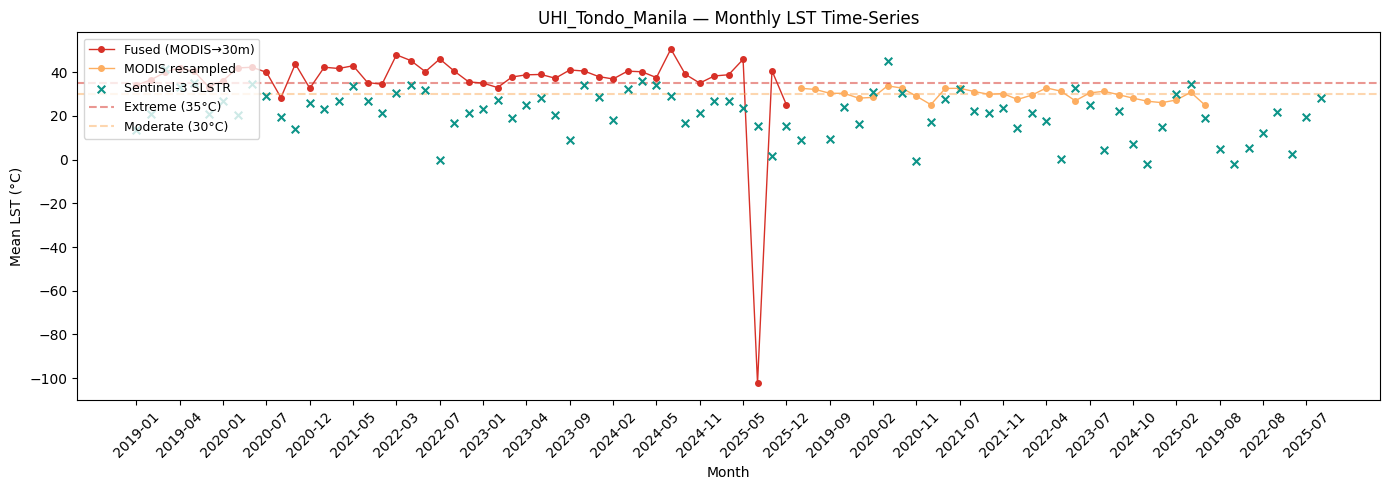

In [14]:
# ----------------------------------------------------------------------
# STEP 7B · Monthly time-series plot
# ----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

# Plot fused LST
valid = monthly_df.dropna(subset=["Mean_LST_fused"])
color_map = {"Fused (MODIS→30m)": "#d73027", "Landsat only": "#4575b4", "MODIS resampled": "#fdae61"}
for method, group in valid.groupby("Method"):
    ax.plot(group["Date"], group["Mean_LST_fused"], "o-",
            color=color_map.get(method, "gray"), label=method, markersize=4, linewidth=1)

# Plot S3 comparison points if available
s3_valid = monthly_df.dropna(subset=["S3_LST"])
if len(s3_valid) > 0:
    ax.scatter(s3_valid["Date"], s3_valid["S3_LST"], marker="x", color="#0d9488",
               s=30, zorder=5, label="Sentinel-3 SLSTR")

# Threshold lines
ax.axhline(LST_EXTREME, color="#d73027", ls="--", lw=1.5, alpha=0.5, label=f"Extreme ({LST_EXTREME}°C)")
ax.axhline(LST_MODERATE, color="#fdae61", ls="--", lw=1.5, alpha=0.5, label=f"Moderate ({LST_MODERATE}°C)")

ax.set_xlabel("Month"); ax.set_ylabel("Mean LST (°C)")
ax.set_title(f"{PROJECT_NAME} — Monthly LST Time-Series")
ax.legend(fontsize=9, loc="upper left")
ax.set_xticks(ax.get_xticks()[::3])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_lst_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 · UHI Intensity Maps

UHI intensity = pixel LST − mean LST of the surrounding reference ring.

Positive values indicate urban heat island effect.


In [15]:
# ----------------------------------------------------------------------
# STEP 8 · UHI intensity
# ----------------------------------------------------------------------

def compute_uhi_intensity(composite, lst_band, label):
    """Compute UHI intensity: pixel LST minus reference ring mean.

    Parameters
    ----------
    composite : ee.Image with the LST band
    lst_band  : str — name of the LST band to use
    label     : str — description for print output

    Returns
    -------
    ee.Image with band 'UHI_intensity'
    """
    lst = composite.select(lst_band)
    reference_mean = ee.Number(
        lst.reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi_ring,
                         scale=30, maxPixels=1e9).get(lst_band)
    )
    uhi = lst.subtract(reference_mean).rename("UHI_intensity")
    print(f"  {label}: reference = {reference_mean.getInfo():.2f} °C")
    return uhi

print("UHI from fused LST:")
uhi_dry    = compute_uhi_intensity(dry_composite, "LST_fused", "Dry")
uhi_wet    = compute_uhi_intensity(wet_composite, "LST_fused", "Wet")
uhi_annual = compute_uhi_intensity(annual_composite, "LST_fused", "Annual")

print("\nUHI from Landsat-only LST (comparison):")
uhi_dry_l    = compute_uhi_intensity(dry_composite, "LST", "Dry")
uhi_wet_l    = compute_uhi_intensity(wet_composite, "LST", "Wet")
uhi_annual_l = compute_uhi_intensity(annual_composite, "LST", "Annual")

UHI from fused LST:
  Dry: reference = 39.02 °C
  Wet: reference = 37.74 °C
  Annual: reference = 38.74 °C

UHI from Landsat-only LST (comparison):
  Dry: reference = 37.83 °C
  Wet: reference = 40.42 °C
  Annual: reference = 38.20 °C


In [16]:
# ----------------------------------------------------------------------
# STEP 8B · Interactive maps: LST and UHI
# ----------------------------------------------------------------------

lst_palette = {"min": 25, "max": 45, "palette": [
    "313695","4575b4","74add1","abd9e9","e0f3f8",
    "ffffbf","fee090","fdae61","f46d43","d73027","a50026"]}
uhi_palette = {"min": -3, "max": 6, "palette": [
    "2166ac","67a9cf","d1e5f0","fddbc7","ef8a62","b2182b"]}
ndvi_palette = {"min": -0.1, "max": 0.6, "palette": [
    "FFFFFF","CE7E45","DF923D","F1B555","FCD163",
    "99B718","74A901","66A000","529400","3E8601","207401","056201"]}

m_lst = make_map(center_lat, center_lon, 14)
add_ee_layer(m_lst, dry_composite.select("LST_fused").clip(aoi), lst_palette, "Fused LST — Dry")
add_ee_layer(m_lst, wet_composite.select("LST_fused").clip(aoi), lst_palette, "Fused LST — Wet", shown=False)
add_ee_layer(m_lst, annual_composite.select("LST").clip(aoi), lst_palette, "Landsat LST — Annual", shown=False)
add_ee_layer(m_lst, uhi_dry.clip(aoi), uhi_palette, "UHI — Dry")
add_ee_layer(m_lst, uhi_wet.clip(aoi), uhi_palette, "UHI — Wet", shown=False)
add_ee_layer(m_lst, annual_composite.select("NDVI").clip(aoi), ndvi_palette, "NDVI", shown=False)
folium.LayerControl().add_to(m_lst)
m_lst

---
## Step 9 · Ancillary Data

In [17]:
# ----------------------------------------------------------------------
# STEP 9 · Ancillary data layers
# ----------------------------------------------------------------------

# A. Population density (WorldPop, latest available year)
pop = (ee.ImageCollection("WorldPop/GP/100m/pop")
       .filterBounds(aoi).sort("system:time_start", False)
       .first().select("population").clip(aoi))
pop_year = ee.Date(pop.get("system:time_start")).format("YYYY").getInfo()
print(f"Population: WorldPop ({pop_year})")

# B. Built-up surface (GHSL)
ghsl = ee.Image("JRC/GHSL/P2023A/GHS_BUILT_S/2020").select("built_surface").clip(aoi)
print("Built-up: GHSL 2020")

# C. Land cover (ESA WorldCover)
esa_lc = ee.ImageCollection("ESA/WorldCover/v200").first().clip(aoi)
print("Land cover: ESA WorldCover 2021")

# D. Health facility proximity (Healthsites via sat-io)
health_dist = None
try:
    health_nodes = ee.FeatureCollection("projects/sat-io/open-datasets/health-site-node").filterBounds(aoi)
    health_ways  = ee.FeatureCollection("projects/sat-io/open-datasets/health-site-way").filterBounds(aoi)
    health_all   = health_nodes.merge(health_ways)
    health_count = health_all.size().getInfo()
    if health_count > 0:
        health_dist = health_all.distance(5000).clip(aoi).rename("health_dist")
        print(f"Health facilities: Healthsites ({health_count} features)")
    else:
        raise Exception("No facilities in AOI")
except Exception:
    health_dist = ee.Image.constant(0).rename("health_dist").clip(aoi).float()
    print("Health facilities: placeholder (set W_HEALTH=0 to exclude)")

# E. Google Open Buildings
try:
    open_buildings = ee.FeatureCollection("GOOGLE/Research/open-buildings/v3/polygons").filterBounds(aoi)
    bldg_count = open_buildings.size().getInfo()
    bldg_raster = open_buildings.reduceToImage(
        properties=["confidence"], reducer=ee.Reducer.count()
    ).rename("building_count").clip(aoi)
    print(f"Buildings: Google Open Buildings ({bldg_count})")
except Exception:
    bldg_raster = ghsl.rename("building_count")
    print("Buildings: using GHSL as proxy")

Population: WorldPop (2020)
Built-up: GHSL 2020
Land cover: ESA WorldCover 2021
Health facilities: Healthsites (93 features)
Buildings: Google Open Buildings (78344)


---
## Step 10 · Statistical Analysis + LST Threshold Classification

Includes:
- Zonal statistics with percentiles (P10 / P25 / P50 / P75 / P90)
- Pixel-level sampling and correlation analysis
- Monthly LST threshold classification (extreme / moderate / cool)
- Heat stress summary by year × season
- Pixel-level heat zone map with area calculations


In [18]:
# ----------------------------------------------------------------------
# STEP 10A · Zonal statistics with percentiles
# ----------------------------------------------------------------------

def zonal_stats(image, band, geometry, scale=30):
    """Compute comprehensive statistics for a band within a geometry."""
    return image.select(band).reduceRegion(
        reducer=(ee.Reducer.mean()
                 .combine(ee.Reducer.minMax(), sharedInputs=True)
                 .combine(ee.Reducer.stdDev(), sharedInputs=True)
                 .combine(ee.Reducer.percentile([10, 25, 50, 75, 90]), sharedInputs=True)),
        geometry=geometry, scale=scale, maxPixels=1e9
    ).getInfo()

rows = []
for season_name, composite in [("Annual", annual_composite), ("Dry", dry_composite), ("Wet", wet_composite)]:
    for band, source in [("LST_fused", "Fused"), ("LST", "Landsat")]:
        s = zonal_stats(composite, band, aoi)
        rows.append({
            "Season": season_name, "Source": source,
            "Mean":   round(s.get(f"{band}_mean", 0), 2),
            "Min":    round(s.get(f"{band}_min", 0), 2),
            "P10":    round(s.get(f"{band}_p10", 0), 2),
            "P25":    round(s.get(f"{band}_p25", 0), 2),
            "Median": round(s.get(f"{band}_p50", 0), 2),
            "P75":    round(s.get(f"{band}_p75", 0), 2),
            "P90":    round(s.get(f"{band}_p90", 0), 2),
            "Max":    round(s.get(f"{band}_max", 0), 2),
            "Std":    round(s.get(f"{band}_stdDev", 0), 2),
        })

stats_df = pd.DataFrame(rows)
print("LST Zonal Statistics (with percentiles)")
print("=" * 110)
print(stats_df.to_string(index=False))

LST Zonal Statistics (with percentiles)
Season  Source  Mean   Min   P10   P25  Median   P75   P90   Max  Std
Annual   Fused 38.27 29.14 35.06 36.69   38.44 39.93 41.06 51.89 2.57
Annual Landsat 42.18 29.59 32.56 41.31   44.06 45.18 45.81 49.60 4.71
   Dry   Fused 38.02 28.11 34.69 36.31   38.06 39.56 40.94 54.27 2.66
   Dry Landsat 42.11 29.39 32.32 41.18   44.06 45.18 45.94 49.48 4.80
   Wet   Fused 39.35 25.98 34.07 36.56   39.94 42.06 43.81 55.86 4.08
   Wet Landsat 42.91 30.16 34.81 41.31   44.06 45.81 47.44 53.31 4.48


Sampled 1754 pixels for correlation analysis.
         BUILT      LST    MNDWI     NDBI     NDVI      POP
count  1754.00  1754.00  1754.00  1754.00  1754.00  1754.00
mean   4074.98    38.29    -0.10     0.03     0.06   550.86
std    1755.22     2.43     0.05     0.03     0.04   804.31
min       0.00    30.97    -0.28    -0.19    -0.03     0.45
25%    3261.00    36.67    -0.14     0.01     0.05   166.20
50%    4478.00    38.43    -0.11     0.03     0.06   374.34
75%    5314.00    39.93    -0.08     0.05     0.07   678.29
max    8940.00    49.96     0.07     0.19     0.35  9543.05


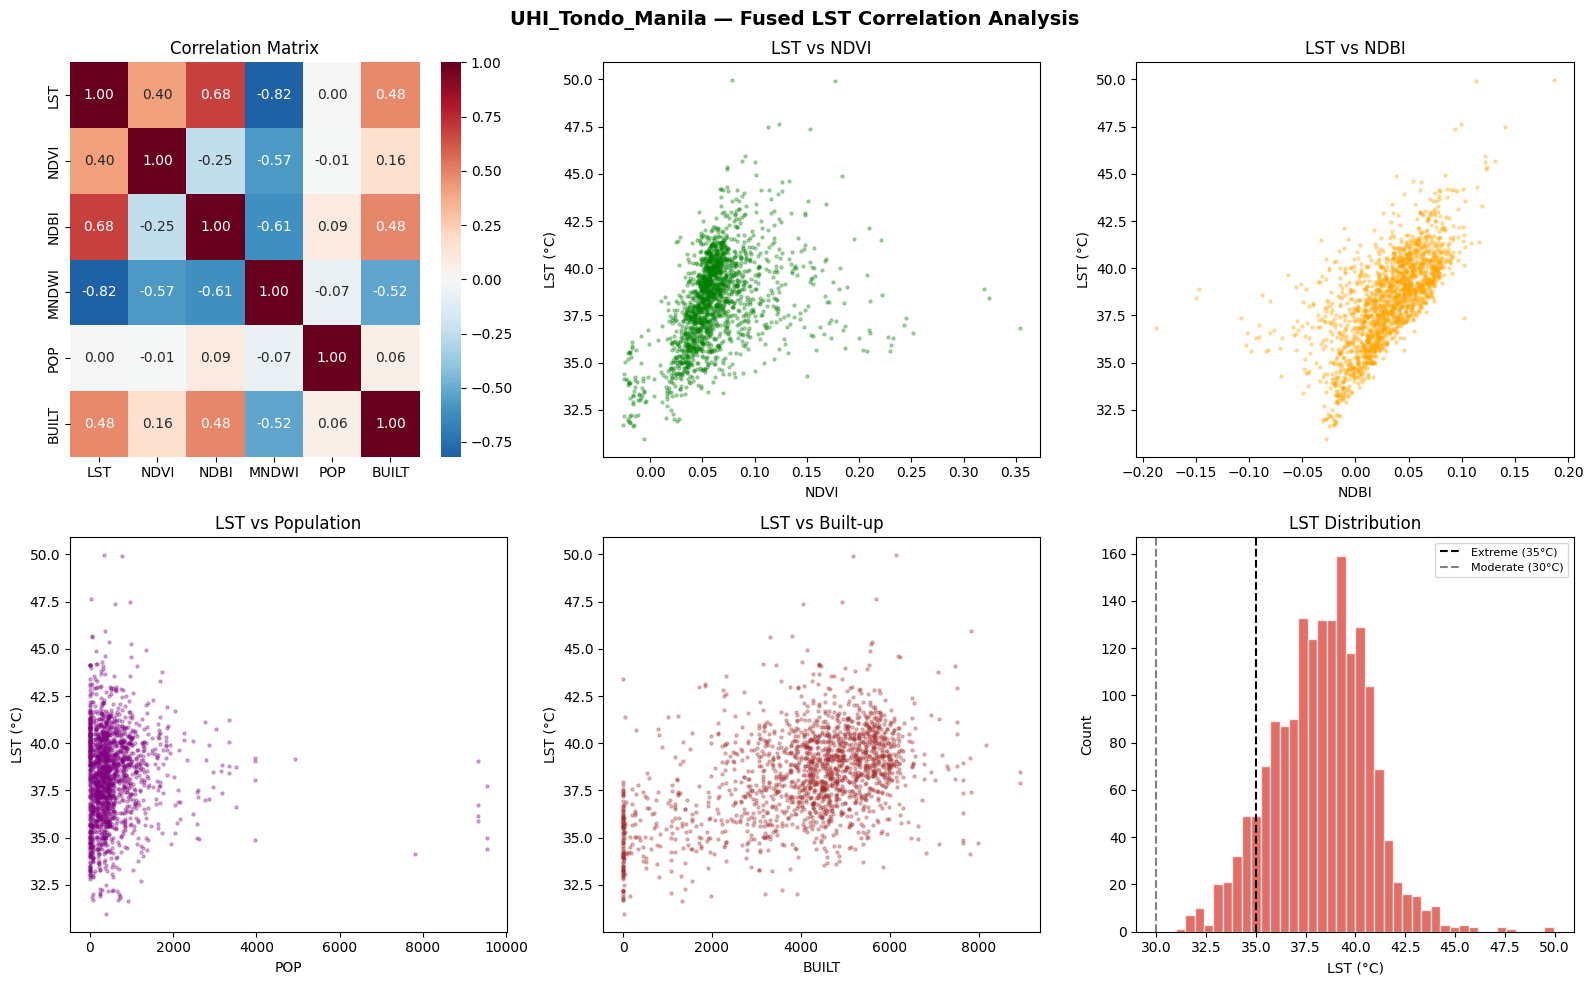

In [19]:
# ----------------------------------------------------------------------
# STEP 10B · Pixel sampling and correlation analysis
# ----------------------------------------------------------------------

sample_stack = (
    annual_composite.select("LST_fused").rename("LST")
    .addBands(annual_composite.select("NDVI"))
    .addBands(annual_composite.select("NDBI"))
    .addBands(annual_composite.select("MNDWI"))
    .addBands(pop.rename("POP"))
    .addBands(ghsl.rename("BUILT"))
)

samples = sample_stack.sample(region=aoi, scale=30, numPixels=2000, seed=42, geometries=False).getInfo()
df = pd.DataFrame([f["properties"] for f in samples["features"]]).dropna()
print(f"Sampled {len(df)} pixels for correlation analysis.")
print(df.describe().round(2))

# Correlation plot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"{PROJECT_NAME} — Fused LST Correlation Analysis", fontsize=14, fontweight="bold")

corr = df[["LST", "NDVI", "NDBI", "MNDWI", "POP", "BUILT"]].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, ax=axes[0, 0], fmt=".2f")
axes[0, 0].set_title("Correlation Matrix")

for ax, col, color, title in [
    (axes[0, 1], "NDVI",  "green",  "LST vs NDVI"),
    (axes[0, 2], "NDBI",  "orange", "LST vs NDBI"),
    (axes[1, 0], "POP",   "purple", "LST vs Population"),
    (axes[1, 1], "BUILT", "brown",  "LST vs Built-up"),
]:
    ax.scatter(df[col], df["LST"], alpha=0.3, s=5, c=color)
    ax.set_xlabel(col); ax.set_ylabel("LST (°C)"); ax.set_title(title)

axes[1, 2].hist(df["LST"], bins=40, color="#d73027", alpha=0.7, edgecolor="white")
axes[1, 2].axvline(LST_EXTREME, color="black", ls="--", lw=1.5, label=f"Extreme ({LST_EXTREME}°C)")
axes[1, 2].axvline(LST_MODERATE, color="gray", ls="--", lw=1.5, label=f"Moderate ({LST_MODERATE}°C)")
axes[1, 2].set_xlabel("LST (°C)"); axes[1, 2].set_ylabel("Count"); axes[1, 2].set_title("LST Distribution")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("lst_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# ----------------------------------------------------------------------
# STEP 10C · Monthly LST threshold classification
# ----------------------------------------------------------------------

valid_months = monthly_df.dropna(subset=["Mean_LST_fused"]).copy()

def classify_month(lst_value):
    if lst_value >= LST_EXTREME:  return "Extreme Heat"
    elif lst_value >= LST_MODERATE: return "Moderate Heat"
    else: return "Cool/Normal"

valid_months["Category"] = valid_months["Mean_LST_fused"].apply(classify_month)
valid_months["Season"] = valid_months["Month"].apply(lambda m: "Dry" if m in DRY_MONTHS else "Wet")

# Summary
print("Monthly LST Threshold Classification")
print("=" * 50)
for cat in ["Extreme Heat", "Moderate Heat", "Cool/Normal"]:
    n = (valid_months["Category"] == cat).sum()
    pct = n / len(valid_months) * 100
    print(f"  {cat:<16s}: {n:3d} months ({pct:.1f}%)")

print(f"\nPercentiles by Season:")
for season in ["Dry", "Wet"]:
    grp = valid_months[valid_months["Season"] == season]["Mean_LST_fused"]
    if len(grp) > 0:
        print(f"  {season}: P10={grp.quantile(0.10):.1f} | P50={grp.quantile(0.50):.1f} | P90={grp.quantile(0.90):.1f}")

Monthly LST Threshold Classification
  Extreme Heat    :  38 months (50.7%)
  Moderate Heat   :  20 months (26.7%)
  Cool/Normal     :  17 months (22.7%)

Percentiles by Season:
  Dry: P10=27.0 | P50=37.2 | P90=42.3
  Wet: P10=28.2 | P50=32.1 | P90=41.0


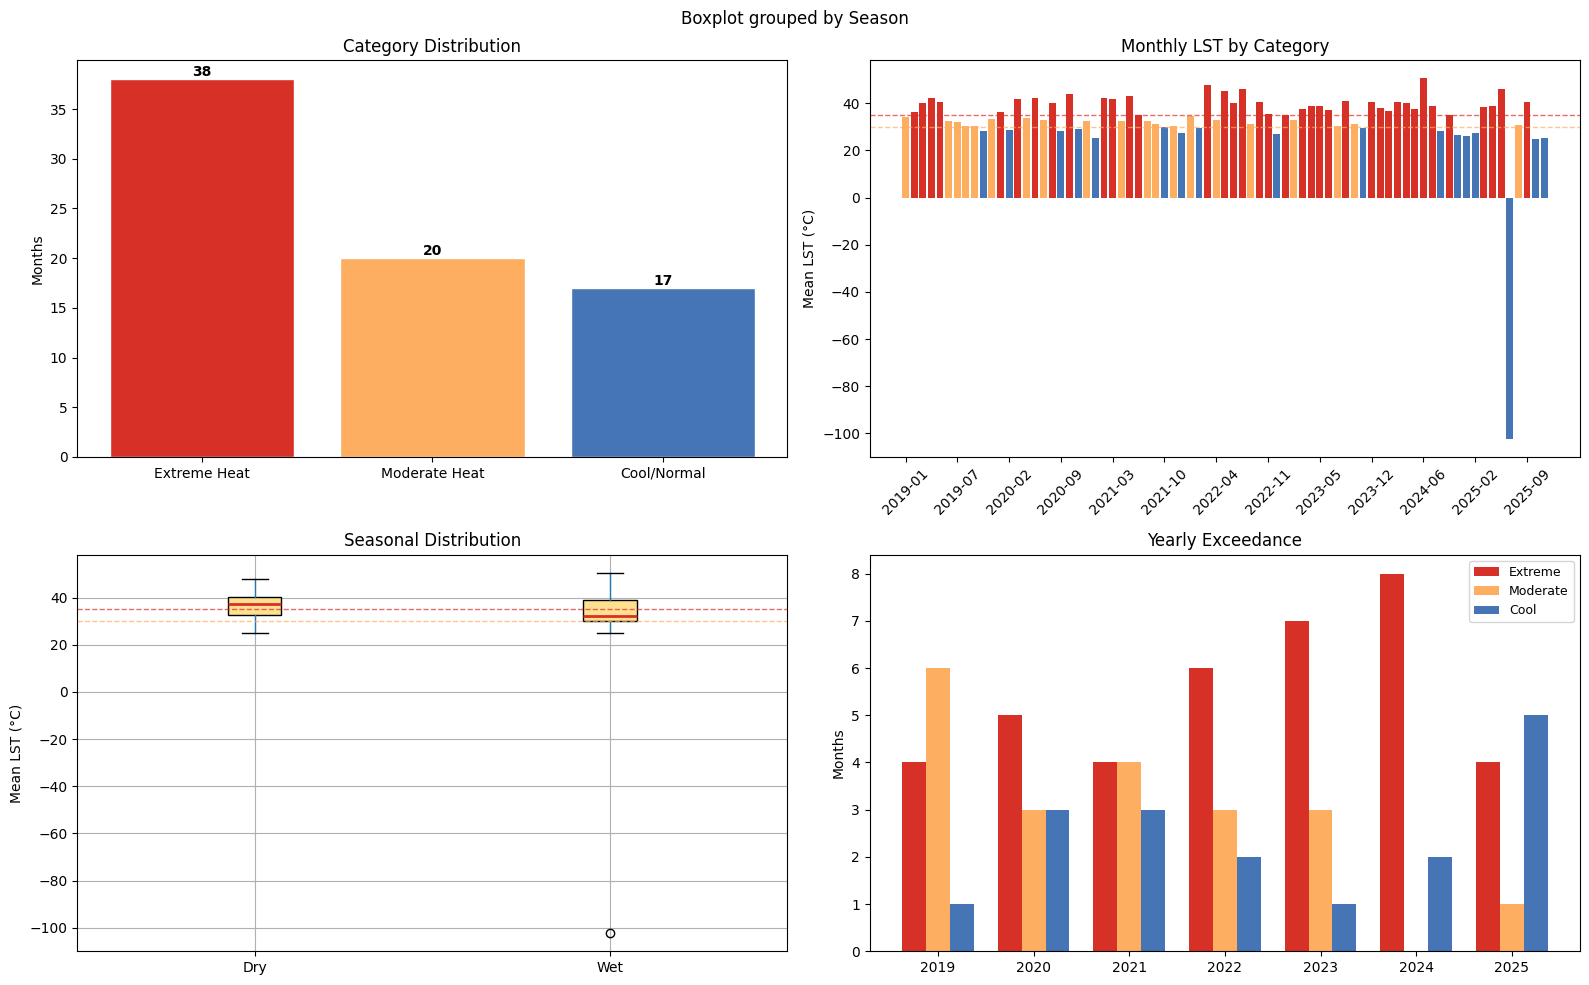

In [21]:
# ----------------------------------------------------------------------
# STEP 10D · Threshold visualizations (4-panel)
# ----------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"{PROJECT_NAME} — LST Threshold Analysis", fontsize=14, fontweight="bold")

cat_colors = {"Extreme Heat": "#d73027", "Moderate Heat": "#fdae61", "Cool/Normal": "#4575b4"}

# (1) Category counts
cats = ["Extreme Heat", "Moderate Heat", "Cool/Normal"]
counts = [int((valid_months["Category"] == c).sum()) for c in cats]
axes[0, 0].bar(cats, counts, color=[cat_colors[c] for c in cats], edgecolor="white")
axes[0, 0].set_ylabel("Months"); axes[0, 0].set_title("Category Distribution")
for i, cnt in enumerate(counts):
    axes[0, 0].text(i, cnt + 0.3, str(cnt), ha="center", fontweight="bold")

# (2) Monthly bars colored by category
for _, row in valid_months.iterrows():
    axes[0, 1].bar(row["Date"], row["Mean_LST_fused"], color=cat_colors[row["Category"]], width=0.8)
axes[0, 1].axhline(LST_EXTREME, color="#d73027", ls="--", lw=1, alpha=0.7)
axes[0, 1].axhline(LST_MODERATE, color="#fdae61", ls="--", lw=1, alpha=0.7)
axes[0, 1].set_ylabel("Mean LST (°C)"); axes[0, 1].set_title("Monthly LST by Category")
axes[0, 1].set_xticks(axes[0, 1].get_xticks()[::6]); axes[0, 1].tick_params(axis="x", rotation=45)

# (3) Seasonal box plots
valid_months.boxplot(column="Mean_LST_fused", by="Season", ax=axes[1, 0], patch_artist=True,
                     boxprops=dict(facecolor="#fee090"), medianprops=dict(color="#d73027", lw=2))
axes[1, 0].axhline(LST_EXTREME, color="#d73027", ls="--", lw=1, alpha=0.7)
axes[1, 0].axhline(LST_MODERATE, color="#fdae61", ls="--", lw=1, alpha=0.7)
axes[1, 0].set_ylabel("Mean LST (°C)"); axes[1, 0].set_title("Seasonal Distribution"); axes[1, 0].set_xlabel("")

# (4) Yearly exceedance
yearly_exc = valid_months.groupby("Year").apply(
    lambda g: pd.Series({
        "Extreme": int((g["Mean_LST_fused"] >= LST_EXTREME).sum()),
        "Moderate": int(((g["Mean_LST_fused"] >= LST_MODERATE) & (g["Mean_LST_fused"] < LST_EXTREME)).sum()),
        "Cool": int((g["Mean_LST_fused"] < LST_MODERATE).sum()),
    })).reset_index()
x = np.arange(len(yearly_exc))
w = 0.25
axes[1, 1].bar(x - w, yearly_exc["Extreme"], w, color="#d73027", label="Extreme")
axes[1, 1].bar(x, yearly_exc["Moderate"], w, color="#fdae61", label="Moderate")
axes[1, 1].bar(x + w, yearly_exc["Cool"], w, color="#4575b4", label="Cool")
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(yearly_exc["Year"].astype(int))
axes[1, 1].set_ylabel("Months"); axes[1, 1].set_title("Yearly Exceedance"); axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("lst_thresholds.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# ----------------------------------------------------------------------
# STEP 10E · Heat stress summary table
# ----------------------------------------------------------------------

summary_rows = []
for yr in sorted(valid_months["Year"].unique()):
    year_data = valid_months[valid_months["Year"] == yr]
    for season in ["Dry", "Wet"]:
        season_data = year_data[year_data["Season"] == season]
        if len(season_data) == 0:
            continue
        summary_rows.append({
            "Year": int(yr), "Season": season,
            "Months": len(season_data),
            "Mean_LST": round(season_data["Mean_LST_fused"].mean(), 2),
            "Max_LST":  round(season_data["Mean_LST_fused"].max(), 2),
            "Min_LST":  round(season_data["Mean_LST_fused"].min(), 2),
            "Extreme":  int((season_data["Mean_LST_fused"] >= LST_EXTREME).sum()),
            "Moderate": int(((season_data["Mean_LST_fused"] >= LST_MODERATE) & (season_data["Mean_LST_fused"] < LST_EXTREME)).sum()),
            "Cool":     int((season_data["Mean_LST_fused"] < LST_MODERATE).sum()),
        })

summary_df = pd.DataFrame(summary_rows)
print("Heat Stress Summary (Year × Season)")
print("=" * 95)
print(summary_df.to_string(index=False))

Heat Stress Summary (Year × Season)
 Year Season  Months  Mean_LST  Max_LST  Min_LST  Extreme  Moderate  Cool
 2019    Dry       6     37.72    42.06    33.19        4         2     0
 2019    Wet       5     30.71    32.63    28.13        0         4     1
 2020    Dry       6     35.88    42.26    28.48        3         2     1
 2020    Wet       5     34.77    43.79    28.34        2         1     2
 2021    Dry       6     35.37    42.96    25.15        3         1     2
 2021    Wet       5     31.84    35.26    29.89        1         3     1
 2022    Dry       6     36.17    47.94    26.93        2         2     2
 2022    Wet       5     38.75    46.06    31.34        4         1     0
 2023    Dry       6     37.35    40.53    32.98        5         1     0
 2023    Wet       5     33.95    41.02    29.71        2         2     1
 2024    Dry       6     36.64    40.48    26.71        5         0     1
 2024    Wet       4     38.20    50.60    28.13        3         0     1
 2

In [23]:
# ----------------------------------------------------------------------
# STEP 10F · Pixel-level heat classification map
# ----------------------------------------------------------------------

fused_lst = annual_composite.select("LST_fused")

extreme_zone  = fused_lst.gte(LST_EXTREME).selfMask().rename("extreme")
moderate_zone = fused_lst.gte(LST_MODERATE).And(fused_lst.lt(LST_EXTREME)).selfMask().rename("moderate")
cool_zone     = fused_lst.lt(LST_MODERATE).selfMask().rename("cool")

# Area calculation
pixel_area = ee.Image.pixelArea()
area_extreme  = (extreme_zone.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=aoi, scale=30, maxPixels=1e9).get("extreme").getInfo() or 0)
area_moderate = (moderate_zone.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=aoi, scale=30, maxPixels=1e9).get("moderate").getInfo() or 0)
area_cool     = (cool_zone.multiply(pixel_area).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=aoi, scale=30, maxPixels=1e9).get("cool").getInfo() or 0)
area_total = area_extreme + area_moderate + area_cool

print("Pixel-Level Heat Classification (Annual Fused LST)")
print("=" * 55)
if area_total > 0:
    print(f"  Extreme (>= {LST_EXTREME}°C) : {area_extreme/1e6:.3f} km²  ({area_extreme/area_total*100:.1f}%)")
    print(f"  Moderate ({LST_MODERATE}–{LST_EXTREME}°C): {area_moderate/1e6:.3f} km²  ({area_moderate/area_total*100:.1f}%)")
    print(f"  Cool (< {LST_MODERATE}°C)     : {area_cool/1e6:.3f} km²  ({area_cool/area_total*100:.1f}%)")

m_heat = make_map(center_lat, center_lon, 14)
add_ee_layer(m_heat, extreme_zone.clip(aoi), {"min":0,"max":1,"palette":["d73027"]}, f"Extreme (≥{LST_EXTREME}°C)")
add_ee_layer(m_heat, moderate_zone.clip(aoi), {"min":0,"max":1,"palette":["fdae61"]}, f"Moderate ({LST_MODERATE}–{LST_EXTREME}°C)")
add_ee_layer(m_heat, cool_zone.clip(aoi), {"min":0,"max":1,"palette":["4575b4"]}, f"Cool (<{LST_MODERATE}°C)", shown=False)
folium.LayerControl().add_to(m_heat)
m_heat

Pixel-Level Heat Classification (Annual Fused LST)
  Extreme (>= 35°C) : 13.708 km²  (86.9%)
  Moderate (30–35°C): 2.067 km²  (13.1%)
  Cool (< 30°C)     : 0.001 km²  (0.0%)


---
## Step 11 · Heat-Exposure Vulnerability Index

Each layer is **min-max normalized** to [0, 1], then weighted and summed.

`Vulnerability = W_LST × LST + W_POP × Pop + W_BUILD × Built + W_NDVI × (1−NDVI) + W_HEALTH × HealthDist`


In [24]:
# ----------------------------------------------------------------------
# STEP 11A · Normalize and compute vulnerability index
# ----------------------------------------------------------------------

def min_max_norm(image, geometry, band_name=None, scale=30):
    """Normalize an image to [0, 1] using min-max within the geometry."""
    if band_name:
        image = image.select(band_name)
    stats = image.reduceRegion(reducer=ee.Reducer.minMax(), geometry=geometry,
                               scale=scale, maxPixels=1e9)
    keys = stats.keys().getInfo()
    min_key = [k for k in keys if "_min" in k][0]
    max_key = [k for k in keys if "_max" in k][0]
    img_min = ee.Number(stats.get(min_key))
    img_max = ee.Number(stats.get(max_key))
    return image.subtract(img_min).divide(img_max.subtract(img_min)).clamp(0, 1)

# Normalize each component
lst_norm   = min_max_norm(annual_composite, aoi, "LST_fused").rename("LST_norm")
pop_norm   = min_max_norm(pop, aoi).rename("POP_norm")
built_norm = min_max_norm(ghsl, aoi).rename("BUILT_norm")
ndvi_norm  = min_max_norm(annual_composite, aoi, "NDVI")
ndvi_inv   = ee.Image.constant(1).subtract(ndvi_norm).rename("NDVI_inv")  # low veg = more vulnerable
health_norm = min_max_norm(health_dist, aoi).rename("HEALTH_norm")

# Weighted sum
vulnerability = (
    lst_norm.multiply(W_LST)
    .add(pop_norm.multiply(W_POP))
    .add(built_norm.multiply(W_BUILD))
    .add(ndvi_inv.multiply(W_NDVI))
    .add(health_norm.multiply(W_HEALTH))
).rename("vulnerability").clip(aoi)

print(f"Vulnerability index computed.")
print(f"  Weights: LST={W_LST}, POP={W_POP}, BUILD={W_BUILD}, NDVI={W_NDVI}, HEALTH={W_HEALTH}")

Vulnerability index computed.
  Weights: LST=0.3, POP=0.25, BUILD=0.2, NDVI=0.15, HEALTH=0.1


In [25]:
# ----------------------------------------------------------------------
# STEP 11B · Vulnerability map
# ----------------------------------------------------------------------

vuln_palette = {"min": 0, "max": 1, "palette": [
    "1a9850","91cf60","d9ef8b","ffffbf","fee08b","fc8d59","d73027"]}

m_vuln = make_map(center_lat, center_lon, 14)
add_ee_layer(m_vuln, vulnerability, vuln_palette, "Vulnerability Index")
add_ee_layer(m_vuln, lst_norm.clip(aoi), {"min":0,"max":1,"palette":["blue","yellow","red"]}, "LST (norm)", shown=False)
add_ee_layer(m_vuln, pop_norm.clip(aoi), {"min":0,"max":1,"palette":["white","purple"]}, "Population (norm)", shown=False)
add_ee_layer(m_vuln, ndvi_inv.clip(aoi), {"min":0,"max":1,"palette":["green","white","brown"]}, "Vegetation Deficit", shown=False)
folium.LayerControl().add_to(m_vuln)
m_vuln

## Step 11C · Barangay-Level Vulnerability Ranking

In [26]:
# ----------------------------------------------------------------------
# STEP 11C · Barangay ranking
# ----------------------------------------------------------------------

try:
    barangays = ee.FeatureCollection(
        "projects/sat-io/open-datasets/geoboundaries/CGAZ_ADM4"
    ).filterBounds(aoi)
    n_brgy = barangays.size().getInfo()
    if n_brgy == 0:
        raise Exception("No features in AOI")

    brgy_vuln = vulnerability.reduceRegions(
        collection=barangays, reducer=ee.Reducer.mean().setOutputs(["vuln_mean"]), scale=30)
    brgy_lst = annual_composite.select("LST_fused").reduceRegions(
        collection=barangays, reducer=ee.Reducer.mean().setOutputs(["lst_mean"]), scale=30)

    ranking = []
    for v, l in zip(brgy_vuln.getInfo()["features"], brgy_lst.getInfo()["features"]):
        name = v["properties"].get("shapeName", v["properties"].get("NAME_4", "Unknown"))
        ranking.append({
            "Barangay": name,
            "Vulnerability": round(v["properties"].get("vuln_mean", 0), 3),
            "Mean LST (°C)": round(l["properties"].get("lst_mean", 0), 2),
        })
    rank_df = pd.DataFrame(ranking).sort_values("Vulnerability", ascending=False)
    print("Barangay Vulnerability Ranking")
    print("=" * 50)
    print(rank_df.to_string(index=False))
except Exception as e:
    print(f"Barangay boundaries not available: {e}")
    print("  Upload a shapefile as a GEE asset and update the path above.")

Barangay boundaries not available: Collection.loadTable: Collection asset 'projects/sat-io/open-datasets/geoboundaries/CGAZ_ADM4' not found.
  Upload a shapefile as a GEE asset and update the path above.


---
## Step 12 · Export + Cooling Sites

In [27]:
# ----------------------------------------------------------------------
# STEP 12A · Export rasters to Google Drive
# ----------------------------------------------------------------------

export_config = dict(region=aoi, scale=30, maxPixels=1e9, crs="EPSG:4326")

exports = [
    (vulnerability.toFloat(),                           "vulnerability_index"),
    (annual_composite.select("LST_fused").toFloat(),    "LST_fused_annual"),
    (annual_composite.select("LST").toFloat(),          "LST_landsat_annual"),
    (uhi_dry.toFloat(),                                 "UHI_dry"),
    (uhi_annual.toFloat(),                              "UHI_annual"),
    (extreme_zone.unmask(0).toFloat(),                  "extreme_heat_mask"),
]

for image, name in exports:
    ee.batch.Export.image.toDrive(
        image=image, description=f"{PROJECT_NAME}_{name}",
        folder=PROJECT_NAME, **export_config
    ).start()
    print(f"  Export started: {name}")

print(f"\nCheck progress: https://code.earthengine.google.com/tasks")

# Save CSVs
stats_df.to_csv("lst_statistics.csv", index=False)
monthly_df.to_csv("monthly_timeseries.csv", index=False)
summary_df.to_csv("heat_stress_summary.csv", index=False)
if "rank_df" in dir():
    rank_df.to_csv("barangay_ranking.csv", index=False)
print("CSV files saved.")

  Export started: vulnerability_index
  Export started: LST_fused_annual
  Export started: LST_landsat_annual
  Export started: UHI_dry
  Export started: UHI_annual
  Export started: extreme_heat_mask

Check progress: https://code.earthengine.google.com/tasks
CSV files saved.


In [28]:
# ----------------------------------------------------------------------
# STEP 12B · Cooling site identification
# ----------------------------------------------------------------------

# ESA WorldCover classes: 10=Trees, 20=Shrub, 30=Grass
cool_landcover = esa_lc.eq(10).Or(esa_lc.eq(20)).Or(esa_lc.eq(30)).selfMask().rename("cool_space")

# High vulnerability zones (top 25%)
vuln_p75 = vulnerability.reduceRegion(
    reducer=ee.Reducer.percentile([75]), geometry=aoi, scale=30, maxPixels=1e9
).get("vulnerability")
high_vuln = vulnerability.gte(ee.Number(vuln_p75)).selfMask()

m_cool = make_map(center_lat, center_lon, 14)
add_ee_layer(m_cool, vulnerability, vuln_palette, "Vulnerability")
add_ee_layer(m_cool, high_vuln.clip(aoi), {"min":0,"max":1,"palette":["red"]}, "High Vulnerability (top 25%)")
add_ee_layer(m_cool, cool_landcover.clip(aoi), {"min":0,"max":1,"palette":["00ff00"]}, "Potential Cool Spaces", shown=False)
folium.LayerControl().add_to(m_cool)
m_cool

---
## Summary (v5)

### What this notebook produces
1. **Landsat 8+9** seasonal composites with LST, NDVI, NDBI, MNDWI (30 m)
2. **MODIS** → regression-based LST fusion to 30 m (with spatial variation)
3. **Sentinel-3 SLSTR** monthly means for temporal calibration
4. **Monthly fused LST** time-series with S3 comparison points
5. **UHI intensity** maps (fused + Landsat comparison)
6. **LST threshold analysis**: extreme / moderate / cool classification
7. **Heat stress summary**: year × season breakdown
8. **Pixel-level heat zone map** with area calculations
9. **Vulnerability index** + barangay ranking
10. **Cooling site** identification
11. **Exported GeoTIFFs + CSVs**

### Architecture
- MODIS provides **spatial** variation for regression downscaling (it's gridded in GEE)
- Sentinel-3 provides **temporal** calibration (independent thermal observations)
- Landsat provides **spectral predictors** at 30 m for the regression model

### To run for a different city
1. Change `AOI_BBOX` in Step 1
2. Adjust season months and thresholds if needed
3. Run all cells

---
*MSF Geo-Humanitarian Project · University of Salzburg Z_GIS*
